In [44]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")


---
## Building the Multi-Layer Perceptron (MLP)

### 2.1 What is an MLP?

A **Multi-Layer Perceptron** is a neural network made of **layers of neurons**, where:

- Every neuron in one layer is connected to **every** neuron in the next layer (this is called being "fully connected" or "dense").
- Information flows in **one direction**: from input, through hidden layers, to output. This is why it is sometimes called a **feedforward neural network**.

An MLP always has **three types of layers**:

| Layer Type | What it does | How many? |
|---|---|---|
| **Input layer** | Receives the raw data (e.g. pixel values, exam scores, sensor readings) | Exactly 1 |
| **Hidden layer(s)** | Transforms the data, extracting patterns that are not obvious in the raw input | 1 or more (this is the "hidden" magic) |
| **Output layer** | Produces the final prediction | Exactly 1 |

> 🏗️ **Analogy:** Think of an MLP like a factory assembly line. Raw materials (input) enter the factory. They pass through several workstations (hidden layers), and at each station, workers (neurons) transform the product a little bit — combining, reshaping, filtering. At the very end, the finished product (output) rolls out. Each "worker" only looks at what came from the *previous* station, and passes their work to the *next* station.

### 2.2 Why "Hidden"?

The hidden layers are called "hidden" simply because we never directly *see* their values in the training data — we only see the inputs (X) and the true outputs (y). What happens inside the hidden layers is the network's own internal representation of the problem — patterns it invents for itself in order to solve the task.

### 2.3 Our Example Network

To learn backpropagation properly, we are going to use one **small, concrete network** throughout this entire notebook, and we will trace exact numbers through it by hand. Here is its architecture:

- **2 input neurons**: $x_1, x_2$
- **1 hidden layer with 2 neurons**: $h_1, h_2$
- **1 output neuron**: $o$

```
   x1 ─────┬────────────┐
           │            │
           ▼            ▼
         (h1) ───┐   (h2) ───┐
           │      │     │    │
   x2 ─────┴──────┼─────┘    │
           │      │          │
           ▼      ▼          ▼
                 (o) ◄───────┘
                  │
                  ▼
              prediction ŷ
```

Every arrow in this diagram carries a **weight**, and every neuron (except the inputs) has a **bias**. That means our tiny network already has:
- $2 \times 2 = 4$ weights from input → hidden ($w_1, w_2, w_3, w_4$)
- $2$ biases for the hidden neurons ($b_{h1}, b_{h2}$)
- $2 \times 1 = 2$ weights from hidden → output ($w_5, w_6$)
- $1$ bias for the output neuron ($b_o$)

**Total: 9 learnable numbers**, called **parameters**. Real-world networks (like the ones behind ChatGPT or self-driving cars) can have **billions** of parameters — but they all work using exactly the same two ideas you're about to learn: **forward propagation** and **backpropagation**.

Let's draw this network visually.


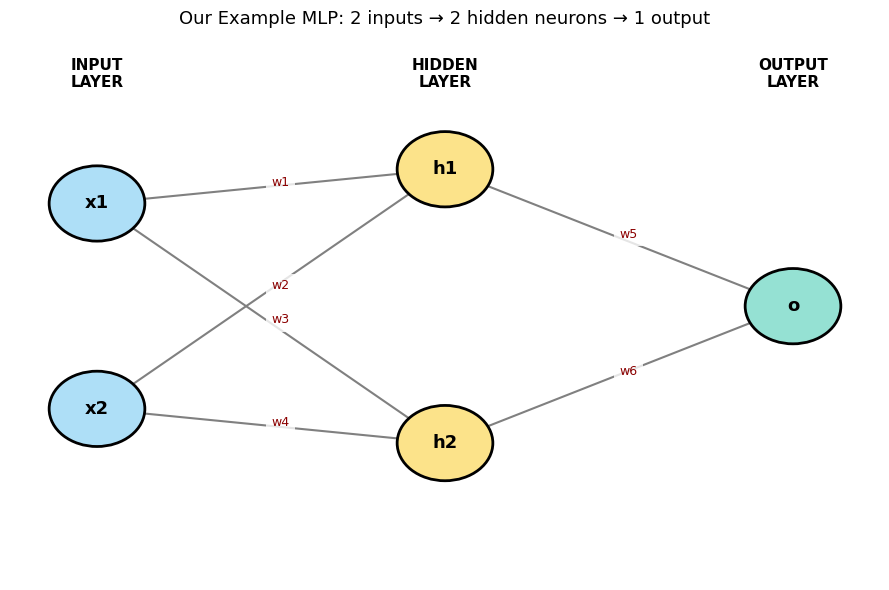

In [36]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(9,6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Positions
input_pos  = {'x1': (1, 5.5), 'x2': (1, 2.5)}
hidden_pos = {'h1': (5, 6),   'h2': (5, 2)}
output_pos = {'o':  (9, 4)}

def draw_neuron(pos, label, color):
    circle = patches.Circle(pos, 0.55, facecolor=color, edgecolor='black', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=13, fontweight='bold', zorder=4)

# Draw connections input -> hidden with weight labels
weight_labels_ih = {('x1','h1'):'w1', ('x2','h1'):'w2', ('x1','h2'):'w3', ('x2','h2'):'w4'}
for (i,h), wl in weight_labels_ih.items():
    p1, p2 = input_pos[i], hidden_pos[h]
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), zorder=1)
    midx, midy = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2
    ax.text(midx, midy, wl, fontsize=9, color='darkred',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# Draw connections hidden -> output
weight_labels_ho = {('h1','o'):'w5', ('h2','o'):'w6'}
for (h,o), wl in weight_labels_ho.items():
    p1, p2 = hidden_pos[h], output_pos[o]
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), zorder=1)
    midx, midy = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2
    ax.text(midx, midy, wl, fontsize=9, color='darkred',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

for name, pos in input_pos.items():
    draw_neuron(pos, name, '#AEDFF7')
for name, pos in hidden_pos.items():
    draw_neuron(pos, name, '#FCE38A')
for name, pos in output_pos.items():
    draw_neuron(pos, name, '#95E1D3')

ax.text(1, 7.2, "INPUT\nLAYER", ha='center', fontsize=11, fontweight='bold')
ax.text(5, 7.2, "HIDDEN\nLAYER", ha='center', fontsize=11, fontweight='bold')
ax.text(9, 7.2, "OUTPUT\nLAYER", ha='center', fontsize=11, fontweight='bold')

plt.title("Our Example MLP: 2 inputs → 2 hidden neurons → 1 output", fontsize=13)
plt.tight_layout()
plt.show()



### 2.4 Activation Functions — Why Do We Need Them?

If we only ever did $z = w \cdot x + b$ and passed that raw number forward, then **stacking layers would be pointless**! Here's why: a straight line, followed by another straight line, followed by another straight line... is still just a straight line. Mathematically, a chain of purely linear operations collapses into one single linear operation. Our whole "multiple lines can separate XOR" idea would fall apart.

This is why every hidden neuron applies a **non-linear activation function** to its weighted sum. Non-linearity is what allows the network to bend, curve, and combine decision boundaries into complex shapes.

The most famous and historically important activation function is the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**What it does:** It takes *any* real number (from $-\infty$ to $+\infty$) and squashes it into the range $(0, 1)$.
- Very negative $z$ → output close to 0
- Very positive $z$ → output close to 1
- $z = 0$ → output exactly $0.5$

This is very convenient because we can interpret the output as a kind of "probability" or "how strongly this neuron is firing."

We will use sigmoid for **every neuron** in our example network (both hidden and output) because it has a wonderfully simple derivative, which will make our backpropagation math clean and easy to follow. (In Act 4, we'll briefly mention other popular activations like ReLU and tanh, which are more common in modern large networks.)

Let's plot the sigmoid function so you can see its S-shape (that's literally what "sigmoid" means — S-shaped!).


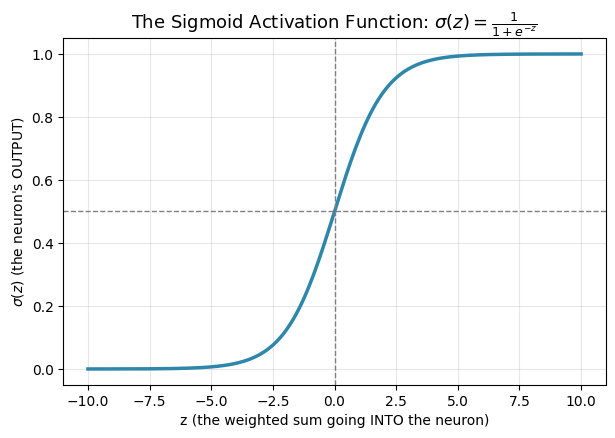

sigmoid(-10) = 4.5397868702434395e-05  -> almost 0
sigmoid(0)   = 0.5  -> exactly 0.5
sigmoid(10)  = 0.9999546021312976  -> almost 1


In [19]:

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 200)
s_vals = sigmoid(z_vals)

plt.figure(figsize=(7,4.5))
plt.plot(z_vals, s_vals, color='#2E86AB', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title(r"The Sigmoid Activation Function: $\sigma(z) = \frac{1}{1+e^{-z}}$", fontsize=13)
plt.xlabel("z (the weighted sum going INTO the neuron)")
plt.ylabel(r"$\sigma(z)$ (the neuron's OUTPUT)")
plt.grid(alpha=0.3)
plt.show()

print("sigmoid(-10) =", sigmoid(-10), " -> almost 0")
print("sigmoid(0)   =", sigmoid(0),   " -> exactly 0.5")
print("sigmoid(10)  =", sigmoid(10),  " -> almost 1")



### 2.5 Forward Propagation — How the Network Makes a Prediction

**Forward propagation** (or the "forward pass") is simply the process of pushing an input through the network, layer by layer, to compute an output prediction. It's exactly what we did conceptually in Act 1's diagram, now with real formulas.

For **each neuron**, forward propagation happens in **two steps**:

**Step A — Compute the weighted sum (often called "net input" or "logit"), denoted $net$:**

$$
net = (\text{sum of each input} \times \text{its weight}) + \text{bias}
$$

**Step B — Apply the activation function to squash it:**

$$
out = \sigma(net)
$$

Let's write this out fully for our specific network.

**Hidden neuron $h_1$:**
$$
net_{h1} = w_1 x_1 + w_2 x_2 + b_{h1} \qquad\qquad out_{h1} = \sigma(net_{h1})
$$

**Hidden neuron $h_2$:**
$$
net_{h2} = w_3 x_1 + w_4 x_2 + b_{h2} \qquad\qquad out_{h2} = \sigma(net_{h2})
$$

**Output neuron $o$** (its inputs are the *outputs* of the hidden layer, NOT the original $x_1, x_2$!):
$$
net_{o} = w_5 \, out_{h1} + w_6 \, out_{h2} + b_{o} \qquad\qquad out_{o} = \sigma(net_{o}) = \hat{y}
$$

This is the key idea to really absorb: **each layer's output becomes the next layer's input.** The hidden layer doesn't see $x_1$ and $x_2$ directly and also send them onward — it processes them into $out_{h1}, out_{h2}$, and THAT is what the output layer sees.

### 2.6 Let's Compute a Real Example, By Hand

To make everything concrete, let's fix actual starting numbers (chosen randomly, the way a real network would be initialized) and a target label, and trace every single number through the network.

**Given:**

| Parameter | Value | | Parameter | Value |
|---|---|---|---|---|
| $x_1$ | 0.05 | | $w_4$ | 0.30 |
| $x_2$ | 0.10 | | $w_5$ | 0.40 |
| $w_1$ | 0.15 | | $w_6$ | 0.45 |
| $w_2$ | 0.20 | | $b_{h1}$ | 0.35 |
| $w_3$ | 0.25 | | $b_{h2}$ | 0.35 |
| | | | $b_o$ | 0.60 |

**Target (true label):** $y = 1$   (we want the network to eventually output something close to 1 for this input)

**Step 1: Compute $net_{h1}$ and $out_{h1}$**

$$
net_{h1} = w_1 x_1 + w_2 x_2 + b_{h1} = (0.15)(0.05) + (0.20)(0.10) + 0.35
$$
$$
net_{h1} = 0.0075 + 0.02 + 0.35 = 0.3775
$$
$$
out_{h1} = \sigma(0.3775) = \frac{1}{1+e^{-0.3775}} \approx 0.59327
$$

**Step 2: Compute $net_{h2}$ and $out_{h2}$**

$$
net_{h2} = w_3 x_1 + w_4 x_2 + b_{h2} = (0.25)(0.05) + (0.30)(0.10) + 0.35
$$
$$
net_{h2} = 0.0125 + 0.03 + 0.35 = 0.3925
$$
$$
out_{h2} = \sigma(0.3925) \approx 0.59688
$$

**Step 3: Compute $net_{o}$ and $out_o$ (the final prediction)**

$$
net_{o} = w_5 \, out_{h1} + w_6 \, out_{h2} + b_o = (0.40)(0.59327) + (0.45)(0.59688) + 0.60
$$
$$
net_{o} \approx 0.23731 + 0.26860 + 0.60 = 1.10591
$$
$$
out_o = \sigma(1.10591) \approx 0.75137
$$

So our network's prediction is $\hat{y} \approx 0.7514$, while the true target is $y = 1$. The network is not exactly right yet — of course not, its weights were just randomly chosen! We haven't trained it at all. This "gap" between prediction and truth is exactly what backpropagation will fix.

Let's verify this by hand-calculation using code, so you can trust every number going forward.


In [20]:

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Given values
x1, x2 = 0.05, 0.10
w1, w2, w3, w4 = 0.15, 0.20, 0.25, 0.30
bh1, bh2 = 0.35, 0.35
w5, w6 = 0.40, 0.45
bo = 0.60
y_target = 1.0

# --- Hidden neuron h1 ---
net_h1 = w1*x1 + w2*x2 + bh1
out_h1 = sigmoid(net_h1)

# --- Hidden neuron h2 ---
net_h2 = w3*x1 + w4*x2 + bh2
out_h2 = sigmoid(net_h2)

# --- Output neuron o ---
net_o = w5*out_h1 + w6*out_h2 + bo
out_o = sigmoid(net_o)

print(f"net_h1 = {net_h1:.5f}   out_h1 = {out_h1:.5f}")
print(f"net_h2 = {net_h2:.5f}   out_h2 = {out_h2:.5f}")
print(f"net_o  = {net_o:.5f}   out_o  = {out_o:.5f}   <-- this is y_hat, our prediction")
print(f"\nTarget y = {y_target}")
print(f"Prediction y_hat = {out_o:.5f}")
print(f"Gap between them = {y_target - out_o:.5f}   <-- backpropagation will try to shrink this")


net_h1 = 0.37750   out_h1 = 0.59327
net_h2 = 0.39250   out_h2 = 0.59688
net_o  = 1.10591   out_o  = 0.75137   <-- this is y_hat, our prediction

Target y = 1.0
Prediction y_hat = 0.75137
Gap between them = 0.24863   <-- backpropagation will try to shrink this



---
## Teaching the Network — Loss, and Backpropagation

We now have a network that can make a prediction (forward propagation). But right now, it's basically guessing — it has never been told whether it's right or wrong. **Act 3 is about learning**: how does the network measure its mistake, and how does it use that mistake to improve itself?

### 3.1 The Loss Function — Measuring "How Wrong Are We?"

We need a single number that tells us how bad a prediction is. This number is called the **loss** (or **error** or **cost**). The simplest and most intuitive choice is the **Squared Error**:

$$
E = \frac{1}{2}(y - \hat{y})^2
$$

Where $y$ is the true target and $\hat{y} = out_o$ is our network's prediction.

**Why squared?**
- Squaring makes the error always **positive** (whether we overshoot or undershoot, being wrong is being wrong).
- Squaring **punishes big mistakes more** than small ones (an error of 2 becomes 4, but an error of 0.1 becomes only 0.01) — this pushes the network to fix its worst mistakes first.

**Why the $\frac{1}{2}$?**
This is purely a mathematical convenience. When we take the derivative of $E$ later, the power rule will bring down a factor of 2, which will cancel neatly with our $\frac{1}{2}$, leaving a clean derivative. It doesn't change *where* the minimum of the loss is, just makes the algebra tidier. (Some textbooks skip it — that's fine too, it only rescales the gradient slightly.)

**Continuing our worked example:**
$$
E = \frac{1}{2}(y - \hat{y})^2 = \frac{1}{2}(1 - 0.75137)^2 = \frac{1}{2}(0.24863)^2 \approx 0.03091
$$

Our goal for training is to **adjust every weight and bias in the network so that $E$ becomes as small as possible.**

### 3.2 The Big Idea: Gradient Descent

Imagine you are standing on a hill in thick fog, and you want to reach the bottom of the valley (the point of lowest error). You can't see the whole landscape, but you *can* feel which direction is "downhill" from where you're standing right now. So a sensible strategy is: **take a small step downhill, then feel again, then take another small step**, and repeat.

This is exactly **Gradient Descent**. The "slope you feel" is the mathematical **gradient** (derivative) of the loss with respect to each weight. If we know how much the loss $E$ would change if we nudged a particular weight $w$ up or down (that's $\frac{\partial E}{\partial w}$), we can update the weight to move *against* that slope (i.e. downhill):

$$
w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial E}{\partial w}
$$

Where $\eta$ (the Greek letter "eta") is the **learning rate** — a small positive number (like 0.1 or 0.5) that controls how big a step we take. Too large, and we might overshoot the valley floor and bounce around. Too small, and training will take forever.

> We subtract because the gradient $\frac{\partial E}{\partial w}$ points in the direction of **steepest increase** in error. To *decrease* error, we move in the *opposite* direction.

So the only missing piece is: **how do we actually calculate $\frac{\partial E}{\partial w}$ for every single weight in the network**, especially for weights buried deep in early layers, far away from where the error is calculated? This is exactly what **Backpropagation** does.

### 3.3 A Quick Refresher: The Chain Rule

Backpropagation is really just a big, organized application of one calculus idea you may have seen before: the **Chain Rule**.

If $y$ depends on $u$, and $u$ depends on $x$, then to find how $y$ changes when $x$ changes, we multiply the "local" rates of change together:

$$
\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}
$$

**Simple analogy:** Suppose your allowance depends on your grades, and your grades depend on how many hours you study.
- If 1 more hour of studying raises your grade by 5 points, and
- 1 more grade point raises your allowance by \$2,

then 1 more hour of studying raises your allowance by $5 \times 2 = \$10$. You just "chained" the two effects together by multiplying them. That's the whole idea — and it works no matter how many links are in the chain.

In our network, the error $E$ depends on $out_o$, which depends on $net_o$, which depends on $out_{h1}$ and $out_{h2}$, which each depend on $net_{h1}$ and $net_{h2}$... which depend on the weights! It's a long chain, and the Chain Rule lets us walk backward through it, one link at a time.

### 3.4 The Derivative of Sigmoid (a Beautiful Shortcut)

Before we dive in, we need one more tool: the derivative of the sigmoid function. It turns out sigmoid has an unusually elegant derivative:

$$
\frac{d\sigma(z)}{dz} = \sigma(z)\big(1 - \sigma(z)\big)
$$

In other words, if you already know a neuron's **output** $out = \sigma(net)$, you can get the derivative for free, just by computing $out \times (1 - out)$ — no need to recompute anything with $net$! This is a big part of why sigmoid was historically so popular for hand-derivable neural networks.

*(You don't need to re-derive this yourself for this class — but for the curious: it comes from applying the quotient rule to $\frac{1}{1+e^{-z}}$. We'll just verify it numerically below.)*


In [21]:

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Numerically verify that d(sigmoid)/dz = sigmoid(z)*(1-sigmoid(z))
z = 0.7775
h = 1e-6  # a tiny step, for numerical (approximate) differentiation

numerical_derivative = (sigmoid(z+h) - sigmoid(z-h)) / (2*h)
formula_derivative = sigmoid(z) * (1 - sigmoid(z))

print("Numerical derivative (tiny-step approximation):", numerical_derivative)
print("Formula sigma(z)*(1-sigma(z))                 :", formula_derivative)
print("They match! This confirms the shortcut formula is correct.")


Numerical derivative (tiny-step approximation): 0.2157227890764446
Formula sigma(z)*(1-sigma(z))                 : 0.2157227891053848
They match! This confirms the shortcut formula is correct.



### 3.5 Backpropagation, Part 1: The Output Layer

Backpropagation always starts at the **output**, where the error is defined, and works **backward** toward the input — hence the name "back"-propagation.

We want to find $\frac{\partial E}{\partial w_5}$ (how much does the total error change if we wiggle weight $w_5$ a tiny bit?). Since $w_5$ affects $E$ only through the chain

$$
w_5 \rightarrow net_o \rightarrow out_o \rightarrow E
$$

the Chain Rule tells us to multiply three "local" derivatives together:

$$
\frac{\partial E}{\partial w_5} = \frac{\partial E}{\partial out_o} \cdot \frac{\partial out_o}{\partial net_o} \cdot \frac{\partial net_o}{\partial w_5}
$$

Let's compute each of these three pieces separately — this is the heart of backpropagation, so let's be very careful.

**Piece 1: $\dfrac{\partial E}{\partial out_o}$**

Recall $E = \frac{1}{2}(y - out_o)^2$. Using the power rule and chain rule on this:

$$
\frac{\partial E}{\partial out_o} = 2 \cdot \frac{1}{2}(y-out_o)^{1} \cdot (-1) = -(y - out_o) = (out_o - y)
$$

**Piece 2: $\dfrac{\partial out_o}{\partial net_o}$**

Since $out_o = \sigma(net_o)$, we use our sigmoid derivative shortcut from Section 3.4:

$$
\frac{\partial out_o}{\partial net_o} = out_o(1-out_o)
$$

**Piece 3: $\dfrac{\partial net_o}{\partial w_5}$**

Recall $net_o = w_5 \cdot out_{h1} + w_6 \cdot out_{h2} + b_o$. Since this is a simple linear equation, the derivative with respect to $w_5$ is just whatever it's multiplied by:

$$
\frac{\partial net_o}{\partial w_5} = out_{h1}
$$

**Putting it together:**

$$
\frac{\partial E}{\partial w_5} = (out_o - y) \cdot out_o(1-out_o) \cdot out_{h1}
$$

This quantity — $\frac{\partial E}{\partial out_o} \cdot \frac{\partial out_o}{\partial net_o}$ — appears so often (it will be reused for $w_6$, and reused again when we go further back) that we give it a special name: $\delta_o$ ("delta o", the **output layer's error signal**):

$$
\delta_o = \frac{\partial E}{\partial net_o} = (out_o - y) \cdot out_o(1-out_o)
$$

So compactly:
$$
\frac{\partial E}{\partial w_5} = \delta_o \cdot out_{h1} \qquad\qquad \frac{\partial E}{\partial w_6} = \delta_o \cdot out_{h2} \qquad\qquad \frac{\partial E}{\partial b_o} = \delta_o \cdot 1 = \delta_o
$$

(The bias's "local input" is always effectively 1, since $net_o$ has a $+b_o$ term with no multiplier — that's why $\frac{\partial net_o}{\partial b_o}=1$.)

**Now let's plug in our real numbers:**

$$
\delta_o = (0.75137 - 1) \times 0.75137 \times (1-0.75137) = (-0.24863)(0.75137)(0.24863)
$$
$$
\delta_o \approx -0.04645
$$

$$
\frac{\partial E}{\partial w_5} = \delta_o \times out_{h1} = (-0.04645)(0.59327) \approx -0.02756
$$
$$
\frac{\partial E}{\partial w_6} = \delta_o \times out_{h2} = (-0.04645)(0.59688) \approx -0.02772
$$
$$
\frac{\partial E}{\partial b_o} = \delta_o \approx -0.04645
$$

**What does a negative gradient mean here?** It means increasing $w_5$ slightly would *decrease* the error — so gradient descent will *increase* $w_5$ a little (remember: $w_{new} = w_{old} - \eta \times \text{gradient}$, and subtracting a negative number means adding).



### 3.6 Backpropagation, Part 2: The Hidden Layer (Where It Gets Interesting)

Now for the trickier part: finding $\frac{\partial E}{\partial w_1}$, the gradient for a weight that is **two layers away** from where the error was calculated. This is where you really see the power of the Chain Rule — and the "back" in backpropagation.

$w_1$ influences the network through this chain:

$$
w_1 \rightarrow net_{h1} \rightarrow out_{h1} \rightarrow net_o \rightarrow out_o \rightarrow E
$$

But here's the crucial subtlety: **$out_{h1}$ doesn't only feed into $E$ through one path** — wait, actually in our small network it does only feed forward through $net_o$, but in general, a hidden neuron's output can influence the error through *multiple* downstream neurons (imagine if the output layer had 2 neurons instead of 1 — $out_{h1}$ would feed both of them). So the correct rule is:

> **The gradient flowing INTO a hidden neuron is the SUM of the gradients coming back from every neuron it feeds forward into.**

In our case, $out_{h1}$ feeds only into $o$, so there's just one term, but we write the general form so you understand the pattern used in bigger networks.

$$
\frac{\partial E}{\partial out_{h1}} = \frac{\partial E}{\partial net_o} \cdot \frac{\partial net_o}{\partial out_{h1}} = \delta_o \cdot w_5
$$

(We already computed $\delta_o$ above! This is backpropagation "reusing" work as it moves backward — much more efficient than recalculating from scratch.)

Now continue the chain down to $w_1$:

$$
\frac{\partial E}{\partial w_1} = \underbrace{\frac{\partial E}{\partial out_{h1}}}_{\text{just found}} \cdot \underbrace{\frac{\partial out_{h1}}{\partial net_{h1}}}_{\text{sigmoid derivative}} \cdot \underbrace{\frac{\partial net_{h1}}{\partial w_1}}_{=\, x_1}
$$

Just like before, we bundle the first two pieces into a hidden-layer error signal $\delta_{h1}$:

$$
\delta_{h1} = \frac{\partial E}{\partial net_{h1}} = \Big(\delta_o \cdot w_5\Big) \cdot out_{h1}(1-out_{h1})
$$

And then:

$$
\frac{\partial E}{\partial w_1} = \delta_{h1} \cdot x_1 \qquad\qquad \frac{\partial E}{\partial w_2} = \delta_{h1} \cdot x_2 \qquad\qquad \frac{\partial E}{\partial b_{h1}} = \delta_{h1}
$$

Similarly, for the other hidden neuron $h_2$:

$$
\delta_{h2} = \Big(\delta_o \cdot w_6\Big) \cdot out_{h2}(1-out_{h2})
$$
$$
\frac{\partial E}{\partial w_3} = \delta_{h2} \cdot x_1 \qquad\qquad \frac{\partial E}{\partial w_4} = \delta_{h2} \cdot x_2 \qquad\qquad \frac{\partial E}{\partial b_{h2}} = \delta_{h2}
$$

**This is the general backpropagation pattern for ANY layer**, and it's worth memorizing the shape of it:

$$
\boxed{\delta_{\text{this layer}} = \Big(\text{sum of } \delta_{\text{next layer}} \times \text{connecting weights}\Big) \times \text{(derivative of this neuron's activation)}}
$$

$$
\boxed{\frac{\partial E}{\partial w_{\text{into this neuron}}} = \delta_{\text{this layer}} \times \text{(the input that came into this neuron along that weight)}}
$$

This is why it's called **back-propagation of error**: the "blame" for the final error is calculated at the output, and then passed backward, layer by layer, getting redistributed among all the neurons and weights that contributed to it — proportionally to how much each one actually contributed (via the weights and activation derivatives).

**Now let's plug in real numbers:**

$$
\delta_{h1} = (\delta_o \cdot w_5) \cdot out_{h1}(1-out_{h1}) = \big((-0.04645)(0.40)\big) \times (0.59327)(0.40673)
$$
$$
\delta_{h1} = (-0.01858) \times (0.24131) \approx -0.00448
$$

$$
\delta_{h2} = (\delta_o \cdot w_6) \cdot out_{h2}(1-out_{h2}) = \big((-0.04645)(0.45)\big) \times (0.59688)(0.40312)
$$
$$
\delta_{h2} = (-0.02090) \times (0.24067) \approx -0.00503
$$

And finally the gradients for the first-layer weights:

$$
\frac{\partial E}{\partial w_1} = \delta_{h1} \cdot x_1 = (-0.00448)(0.05) \approx -0.000224
$$
$$
\frac{\partial E}{\partial w_2} = \delta_{h1} \cdot x_2 = (-0.00448)(0.10) \approx -0.000448
$$
$$
\frac{\partial E}{\partial w_3} = \delta_{h2} \cdot x_1 = (-0.00503)(0.05) \approx -0.000251
$$
$$
\frac{\partial E}{\partial w_4} = \delta_{h2} \cdot x_2 = (-0.00503)(0.10) \approx -0.000503
$$

Notice something important: **these gradients are much smaller in magnitude** than the output layer's gradients ($\approx$ 0.0002 vs $\approx$ 0.03). This is a first hint of a real phenomenon in deep learning called the **vanishing gradient problem** — gradients tend to shrink as they propagate backward through many layers, which can make early layers of very deep networks learn very slowly. (This is one reason modern networks often prefer activation functions other than sigmoid, like ReLU, which we'll mention in Act 4.)

Let's now verify ALL of these gradients with code.


In [37]:

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative_from_output(out):
    # If out = sigmoid(net), this returns d(out)/d(net)
    return out * (1 - out)

# ---- Forward pass (recomputing, so this cell is self-contained) ----
x1, x2 = 0.05, 0.10
w1, w2, w3, w4 = 0.15, 0.20, 0.25, 0.30
bh1, bh2 = 0.35, 0.35
w5, w6 = 0.40, 0.45
bo = 0.60
y_target = 1.0

net_h1 = w1*x1 + w2*x2 + bh1
out_h1 = sigmoid(net_h1)
net_h2 = w3*x1 + w4*x2 + bh2
out_h2 = sigmoid(net_h2)
net_o  = w5*out_h1 + w6*out_h2 + bo
out_o  = sigmoid(net_o)

E = 0.5 * (y_target - out_o)**2
print(f"Forward pass check -> out_h1={out_h1:.5f}, out_h2={out_h2:.5f}, out_o={out_o:.5f}, Loss E={E:.5f}\n")

# ---- Backward pass ----
# Output layer delta
delta_o = (out_o - y_target) * sigmoid_derivative_from_output(out_o)
print(f"delta_o = {delta_o:.5f}")

dE_dw5 = delta_o * out_h1
dE_dw6 = delta_o * out_h2
dE_dbo = delta_o
print(f"dE/dw5 = {dE_dw5:.6f}")
print(f"dE/dw6 = {dE_dw6:.6f}")
print(f"dE/dbo = {dE_dbo:.6f}\n")

# Hidden layer deltas
delta_h1 = (delta_o * w5) * sigmoid_derivative_from_output(out_h1)
delta_h2 = (delta_o * w6) * sigmoid_derivative_from_output(out_h2)
print(f"delta_h1 = {delta_h1:.6f}")
print(f"delta_h2 = {delta_h2:.6f}")

dE_dw1 = delta_h1 * x1
dE_dw2 = delta_h1 * x2
dE_dw3 = delta_h2 * x1
dE_dw4 = delta_h2 * x2
dE_dbh1 = delta_h1
dE_dbh2 = delta_h2

print(f"\ndE/dw1 = {dE_dw1:.7f}")
print(f"dE/dw2 = {dE_dw2:.7f}")
print(f"dE/dw3 = {dE_dw3:.7f}")
print(f"dE/dw4 = {dE_dw4:.7f}")
print(f"dE/dbh1 = {dE_dbh1:.6f}")
print(f"dE/dbh2 = {dE_dbh2:.6f}")

print("\nAll values match our hand-worked calculations above.")


Forward pass check -> out_h1=0.59327, out_h2=0.59688, out_o=0.75137, Loss E=0.03091

delta_o = -0.04645
dE/dw5 = -0.027557
dE/dw6 = -0.027725
dE/dbo = -0.046449

delta_h1 = -0.004483
delta_h2 = -0.005029

dE/dw1 = -0.0002242
dE/dw2 = -0.0004483
dE/dw3 = -0.0002515
dE/dw4 = -0.0005029
dE/dbh1 = -0.004483
dE/dbh2 = -0.005029

All values match our hand-worked calculations above.



### 3.7 The Final Step: Updating All the Weights (Gradient Descent Update)

Now that we have every single gradient, we apply the gradient descent rule to **every parameter simultaneously**, using a learning rate $\eta = 0.5$ (a fairly large learning rate, chosen here just to make the change visible in one step — in practice, learning rates are often much smaller, like 0.01, and training happens over thousands of steps):

$$
w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial E}{\partial w}
$$

**Important subtlety:** all weights should be updated **using the OLD values of every other weight** — that is, we compute all the gradients first (using the original forward pass), and only after all gradients are known do we update every weight together. If we updated $w_5$ first and then used the *new* $w_5$ to compute $\delta_{h1}$, our math would be inconsistent. This is why we always fully finish the forward pass and the entire backward pass (computing all deltas and all gradients) before touching any weight.

Let's compute the updated weights.


In [38]:

lr = 0.5  # learning rate (eta)

w1_new = w1 - lr * dE_dw1
w2_new = w2 - lr * dE_dw2
w3_new = w3 - lr * dE_dw3
w4_new = w4 - lr * dE_dw4
bh1_new = bh1 - lr * dE_dbh1
bh2_new = bh2 - lr * dE_dbh2
w5_new = w5 - lr * dE_dw5
w6_new = w6 - lr * dE_dw6
bo_new = bo - lr * dE_dbo

print("Parameter   Old Value   ->   New Value")
print(f"w1          {w1:.5f}     ->   {w1_new:.5f}")
print(f"w2          {w2:.5f}     ->   {w2_new:.5f}")
print(f"w3          {w3:.5f}     ->   {w3_new:.5f}")
print(f"w4          {w4:.5f}     ->   {w4_new:.5f}")
print(f"bh1         {bh1:.5f}     ->   {bh1_new:.5f}")
print(f"bh2         {bh2:.5f}     ->   {bh2_new:.5f}")
print(f"w5          {w5:.5f}     ->   {w5_new:.5f}")
print(f"w6          {w6:.5f}     ->   {w6_new:.5f}")
print(f"bo          {bo:.5f}     ->   {bo_new:.5f}")

# Let's do ONE more forward pass with the NEW weights, to prove the error actually went down!
net_h1_2 = w1_new*x1 + w2_new*x2 + bh1_new
out_h1_2 = sigmoid(net_h1_2)
net_h2_2 = w3_new*x1 + w4_new*x2 + bh2_new
out_h2_2 = sigmoid(net_h2_2)
net_o_2  = w5_new*out_h1_2 + w6_new*out_h2_2 + bo_new
out_o_2  = sigmoid(net_o_2)
E_2 = 0.5 * (y_target - out_o_2)**2

print(f"\nOLD prediction: {out_o:.5f}   OLD loss: {E:.5f}")
print(f"NEW prediction: {out_o_2:.5f}   NEW loss: {E_2:.5f}")
print(f"\nThe loss decreased! Our single step of gradient descent made the network")
print(f"a little bit better at predicting y=1 for this input. This is learning, one tiny step at a time.")


Parameter   Old Value   ->   New Value
w1          0.15000     ->   0.15011
w2          0.20000     ->   0.20022
w3          0.25000     ->   0.25013
w4          0.30000     ->   0.30025
bh1         0.35000     ->   0.35224
bh2         0.35000     ->   0.35251
w5          0.40000     ->   0.41378
w6          0.45000     ->   0.46386
bo          0.60000     ->   0.62322

OLD prediction: 0.75137   OLD loss: 0.03091
NEW prediction: 0.75880   NEW loss: 0.02909

The loss decreased! Our single step of gradient descent made the network
a little bit better at predicting y=1 for this input. This is learning, one tiny step at a time.



### 3.8 Zooming Out: What Did We Just Do?

Let's summarize the whole backpropagation algorithm in words, now that you've seen every piece of the math:

1. **Forward pass:** Push the input through the network to get a prediction $\hat{y}$, and compute the loss $E$ compared to the true target $y$.
2. **Compute output-layer error signal ($\delta_o$):** How sensitive is the loss to the output neuron's net input?
3. **Compute output-layer gradients:** Multiply $\delta_o$ by whatever fed into that weight (i.e., the hidden layer's outputs), to get $\frac{\partial E}{\partial w}$ for every output-layer weight.
4. **Propagate error backward to the hidden layer:** Each hidden neuron's error signal $\delta_h$ is a weighted sum of the $\delta$'s "in front of it" (from the layer closer to the output), multiplied by its own activation derivative.
5. **Compute hidden-layer gradients:** Multiply each $\delta_h$ by whatever fed into that weight (i.e., the original inputs), to get $\frac{\partial E}{\partial w}$ for every hidden-layer weight.
6. **Update ALL weights and biases** simultaneously using gradient descent: $w \leftarrow w - \eta \frac{\partial E}{\partial w}$.
7. **Repeat** this entire process (forward pass → backward pass → update) for many, many training examples, over and over (each full pass through all training data is called an **epoch**) — and the network gradually gets better and better.

> **The one-sentence summary of backpropagation:** *"Figure out how much each neuron contributed to the final error, by walking backward through the network and repeatedly applying the chain rule, and then nudge every weight in the direction that would have reduced that error."*



---
## Building a Complete MLP From Scratch in Python

Now that we understand every formula by hand, let's write a general-purpose MLP class that can:
1. Do a forward pass for any input
2. Do a full backward pass (backpropagation) to compute all gradients
3. Update all its weights using gradient descent
4. Repeat this over many training examples and epochs until it learns

We will build it generally enough to handle **any** number of hidden neurons (not just 2), so we can also solve the XOR problem from Act 1 — the very problem a single perceptron could never solve!

### 4.1 The Plan

Our class will store:
- `W1`: weight matrix from input layer → hidden layer
- `b1`: bias vector for the hidden layer
- `W2`: weight matrix from hidden layer → output layer
- `b2`: bias vector for the output layer

Using matrices lets us process a whole batch of training examples at once (very efficient), instead of looping one-by-one like we did by hand. But the underlying math is **identical** to what we derived above — matrices are just a compact way of writing many simultaneous multiplications and sums.


In [39]:

import numpy as np

np.random.seed(42)  # for reproducible results

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(out):
    # out is already sigmoid(z), so this is the "free" shortcut derivative
    return out * (1 - out)


class SimpleMLP:
    def __init__(self, n_input, n_hidden, n_output, learning_rate=0.5):
        # Small random initial weights -- if all weights started at 0,
        # every hidden neuron would compute the exact same thing forever
        # (this is called the "symmetry problem"), so we must randomize.
        self.W1 = np.random.uniform(-1, 1, (n_input, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.uniform(-1, 1, (n_hidden, n_output))
        self.b2 = np.zeros((1, n_output))
        self.lr = learning_rate
        self.loss_history = []

    def forward(self, X):
        # X has shape (num_examples, n_input)
        self.net_h = X @ self.W1 + self.b1          # weighted sum into hidden layer
        self.out_h = sigmoid(self.net_h)             # hidden layer activations
        self.net_o = self.out_h @ self.W2 + self.b2   # weighted sum into output layer
        self.out_o = sigmoid(self.net_o)              # final prediction
        return self.out_o

    def backward(self, X, y):
        m = X.shape[0]  # number of training examples in this batch

        # ----- Output layer -----
        # delta_o = dE/dnet_o for every example and every output neuron
        delta_o = (self.out_o - y) * sigmoid_derivative(self.out_o)

        dW2 = self.out_h.T @ delta_o / m     # average gradient over the batch
        db2 = np.sum(delta_o, axis=0, keepdims=True) / m

        # ----- Hidden layer -----
        # Propagate the error backward through W2
        delta_h = (delta_o @ self.W2.T) * sigmoid_derivative(self.out_h)

        dW1 = X.T @ delta_h / m
        db1 = np.sum(delta_h, axis=0, keepdims=True) / m

        # ----- Gradient descent update -----
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=5000, verbose_every=500):
        for epoch in range(epochs):
            self.forward(X)
            loss = np.mean(0.5 * (y - self.out_o) ** 2)
            self.loss_history.append(loss)
            self.backward(X, y)
            if epoch % verbose_every == 0:
                print(f"Epoch {epoch:5d}  |  Loss: {loss:.6f}")

    def predict(self, X):
        return self.forward(X)

print("SimpleMLP class defined. Notice how forward() and backward() are DIRECT")
print("translations of the formulas we derived by hand in Act 2 and Act 3!")


SimpleMLP class defined. Notice how forward() and backward() are DIRECT
translations of the formulas we derived by hand in Act 2 and Act 3!



### 4.2 Sanity Check: Reproduce Our Hand-Worked Example

Before tackling XOR, let's plug our exact Act 2/3 numbers into this class and confirm it reproduces the same forward pass and gradients we calculated by hand. This is good scientific practice: always verify new code against a known, trusted answer before trusting it with something new.


In [41]:

# Build a network with the SAME architecture as our hand example: 2 inputs, 2 hidden, 1 output
mlp_check = SimpleMLP(n_input=2, n_hidden=2, n_output=1, learning_rate=0.5)

# Manually overwrite its random weights with our EXACT hand-worked values
mlp_check.W1 = np.array([[0.15, 0.25],
                          [0.20, 0.30]])   # rows=inputs(x1,x2), cols=hidden neurons(h1,h2)
mlp_check.b1 = np.array([[0.35, 0.35]])
mlp_check.W2 = np.array([[0.40],
                          [0.45]])          # rows=hidden(h1,h2), col=output(o)
mlp_check.b2 = np.array([[0.60]])

X_check = np.array([[0.05, 0.10]])
y_check = np.array([[1.0]])

pred = mlp_check.forward(X_check)
print("Predicted output:", pred[0,0], "  (we calculated by hand: 0.75137)")

mlp_check.backward(X_check, y_check)
print("\nAfter one backprop + update step:")
print("New W1 (w1, w3 / w2, w4):\n", mlp_check.W1, "  (hand-calc: w1=0.15011, w2=0.20022, w3=0.25013, w4=0.30025)")
print("New W2 (w5, w6):\n", mlp_check.W2.ravel(), "  (hand-calc: w5=0.41378, w6=0.46386)")
print("\nGreat -- our general-purpose class exactly matches our hand-worked example!")


Predicted output: 0.7513650695523157   (we calculated by hand: 0.75137)

After one backprop + update step:
New W1 (w1, w3 / w2, w4):
 [[0.15011208 0.25012573]
 [0.20022416 0.30025147]]   (hand-calc: w1=0.15011, w2=0.20022, w3=0.25013, w4=0.30025)
New W2 (w5, w6):
 [0.41377836 0.46386231]   (hand-calc: w5=0.41378, w6=0.46386)

Great -- our general-purpose class exactly matches our hand-worked example!



### 4.3 The Real Test: Solving XOR

Now for the moment of truth. Recall from Act 1 that a **single** perceptron mathematically **cannot** solve XOR. Let's see if our MLP, with its hidden layer, can succeed where a lone neuron fails.


In [42]:

# The XOR dataset, reshaped for matrix operations
X_xor = np.array([[0,0],
                   [0,1],
                   [1,0],
                   [1,1]], dtype=float)

y_xor = np.array([[0],
                   [1],
                   [1],
                   [0]], dtype=float)

# A fresh network: 2 inputs, 4 hidden neurons (a bit more room to learn), 1 output
xor_net = SimpleMLP(n_input=2, n_hidden=4, n_output=1, learning_rate=1.0)

print("Training on XOR...\n")
xor_net.train(X_xor, y_xor, epochs=10000, verbose_every=1000)

print("\n--- Final predictions ---")
final_preds = xor_net.predict(X_xor)
for inputs, target, pred in zip(X_xor, y_xor, final_preds):
    rounded = 1 if pred[0] > 0.5 else 0
    print(f"Input: {inputs}   Target: {int(target[0])}   Raw prediction: {pred[0]:.4f}   Rounded: {rounded}")


Training on XOR...

Epoch     0  |  Loss: 0.131767
Epoch  1000  |  Loss: 0.120682
Epoch  2000  |  Loss: 0.054814
Epoch  3000  |  Loss: 0.006199
Epoch  4000  |  Loss: 0.002227
Epoch  5000  |  Loss: 0.001266
Epoch  6000  |  Loss: 0.000864
Epoch  7000  |  Loss: 0.000649
Epoch  8000  |  Loss: 0.000516
Epoch  9000  |  Loss: 0.000427

--- Final predictions ---
Input: [0. 0.]   Target: 0   Raw prediction: 0.0230   Rounded: 0
Input: [0. 1.]   Target: 1   Raw prediction: 0.9717   Rounded: 1
Input: [1. 0.]   Target: 1   Raw prediction: 0.9776   Rounded: 1
Input: [1. 1.]   Target: 0   Raw prediction: 0.0328   Rounded: 0



If training went well, you should see the raw predictions land very close to 0 or 1 in exactly the pattern XOR requires, and the "Rounded" column should perfectly match the "Target" column. **Our multi-layer network solved a problem that is mathematically impossible for a single perceptron** — this is the entire point of stacking layers!

Let's visualize the loss decreasing over training (this is called a **learning curve**), and also visualize the actual decision boundary the network has learned.


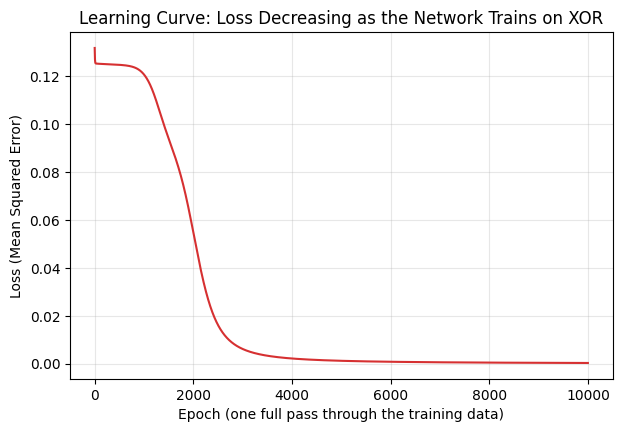

Notice how the loss starts high (the network is guessing randomly) and
drops toward zero as backpropagation repeatedly nudges the weights in
the direction that reduces error.


In [43]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4.5))
plt.plot(xor_net.loss_history, color='#D63031', linewidth=1.5)
plt.xlabel("Epoch (one full pass through the training data)")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Learning Curve: Loss Decreasing as the Network Trains on XOR")
plt.grid(alpha=0.3)
plt.show()

print("Notice how the loss starts high (the network is guessing randomly) and")
print("drops toward zero as backpropagation repeatedly nudges the weights in")
print("the direction that reduces error.")


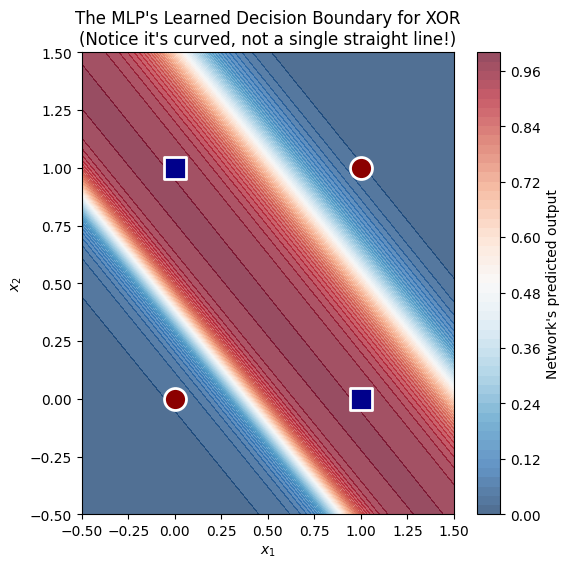

This curved / bent decision boundary is exactly what a single perceptron
could never draw. The hidden layer let the network combine multiple
simple boundaries into a shape complex enough to solve XOR.


In [28]:

import numpy as np
import matplotlib.pyplot as plt

# Create a fine grid of points covering the input space
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Ask the trained network to predict on every point in the grid
grid_preds = xor_net.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6,6))
# Shade the background according to what the network predicts (its "decision surface")
contour = plt.contourf(xx, yy, grid_preds, levels=50, cmap='RdBu_r', alpha=0.7)
plt.colorbar(contour, label="Network's predicted output")

# Overlay the actual XOR training points
for point, label in zip(X_xor, y_xor.ravel()):
    color = 'darkred' if label == 0 else 'darkblue'
    marker = 'o' if label == 0 else 's'
    plt.scatter(point[0], point[1], c=color, marker=marker, s=250,
                edgecolors='white', linewidths=2, zorder=5)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("The MLP's Learned Decision Boundary for XOR\n(Notice it's curved, not a single straight line!)")
plt.show()

print("This curved / bent decision boundary is exactly what a single perceptron")
print("could never draw. The hidden layer let the network combine multiple")
print("simple boundaries into a shape complex enough to solve XOR.")



### 4.4 A Quick Look at Other Activation Functions

We used sigmoid throughout this notebook because its derivative is simple and beautiful for learning the math by hand. But in practice, especially in bigger modern networks, other activation functions are often preferred. Here are the two most common ones you'll encounter:

**Tanh (hyperbolic tangent):**
$$
\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
$$
Similar S-shape to sigmoid, but squashes values into $(-1, 1)$ instead of $(0,1)$. Often trains a bit better than sigmoid because it's centered around 0.

**ReLU (Rectified Linear Unit):**
$$
\text{ReLU}(z) = \max(0, z)
$$
This one is surprisingly simple: if the input is negative, output 0; if positive, output the input unchanged. Despite (or because of) its simplicity, ReLU is the most widely used activation function in modern deep learning, because it's very fast to compute and helps avoid the vanishing gradient problem we mentioned in Section 3.6.

Let's plot all three side by side.


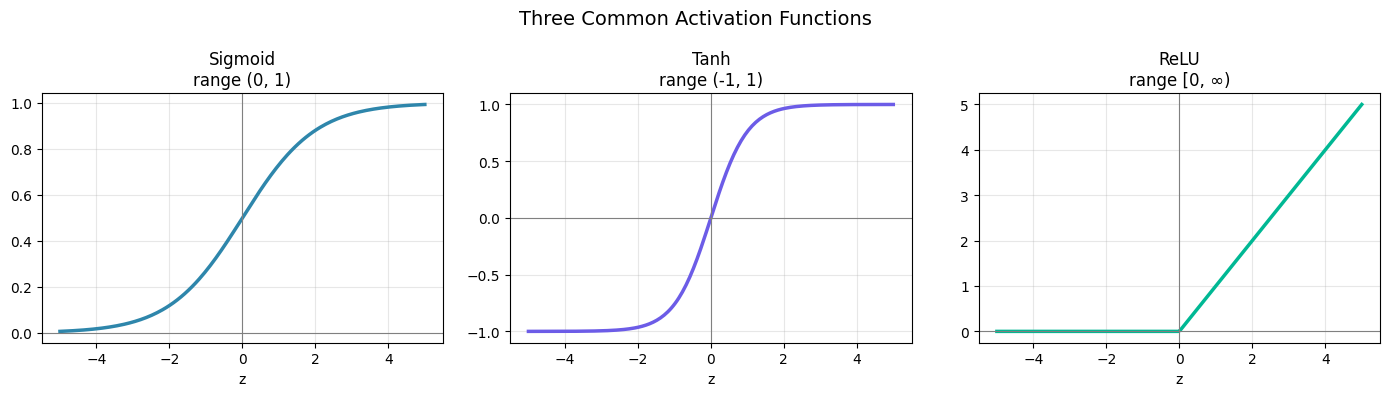

In [29]:

import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)

sigmoid_vals = 1 / (1 + np.exp(-z))
tanh_vals = np.tanh(z)
relu_vals = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(z, sigmoid_vals, color='#2E86AB', linewidth=2.5)
axes[0].set_title("Sigmoid\nrange (0, 1)")
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.8)

axes[1].plot(z, tanh_vals, color='#6C5CE7', linewidth=2.5)
axes[1].set_title("Tanh\nrange (-1, 1)")
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', linewidth=0.8)

axes[2].plot(z, relu_vals, color='#00B894', linewidth=2.5)
axes[2].set_title("ReLU\nrange [0, ∞)")
axes[2].grid(alpha=0.3)
axes[2].axhline(0, color='gray', linewidth=0.8)

for ax in axes:
    ax.set_xlabel("z")
    ax.axvline(0, color='gray', linewidth=0.8)

plt.suptitle("Three Common Activation Functions", fontsize=14)
plt.tight_layout()
plt.show()



### Comparing to a Professional Library

Everything above was written completely from scratch, using only NumPy, so you could see every single multiplication and addition involved in forward and backward propagation. In real projects, data scientists usually use well-tested libraries instead of writing this by hand every time. Here's the same XOR problem solved using **scikit-learn**'s `MLPClassifier`, just so you can see that the concepts transfer directly — it's the exact same idea (layers, weights, backprop, gradient descent), just with a convenient, optimized interface.


In [30]:

from sklearn.neural_network import MLPClassifier

# hidden_layer_sizes=(4,) means: one hidden layer with 4 neurons (just like our from-scratch network)
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic',
                             solver='lbfgs', max_iter=5000, random_state=42)

sklearn_mlp.fit(X_xor, y_xor.ravel())

print("scikit-learn MLP predictions on XOR:")
sk_preds = sklearn_mlp.predict(X_xor)
for inputs, target, pred in zip(X_xor, y_xor.ravel(), sk_preds):
    print(f"Input: {inputs}   Target: {int(target)}   Predicted: {pred}")

print(f"\nAccuracy: {sklearn_mlp.score(X_xor, y_xor.ravel())*100:.1f}%")
print("\n'activation=logistic' is scikit-learn's name for the sigmoid function we used by hand.")
print("('solver=lbfgs' is a smarter, faster optimizer than plain gradient descent -- great for")
print(" small datasets like this one -- but it's built on the exact same gradients from backprop!)")


scikit-learn MLP predictions on XOR:
Input: [0. 0.]   Target: 0   Predicted: 0.0
Input: [0. 1.]   Target: 1   Predicted: 1.0
Input: [1. 0.]   Target: 1   Predicted: 1.0
Input: [1. 1.]   Target: 0   Predicted: 0.0

Accuracy: 100.0%

'activation=logistic' is scikit-learn's name for the sigmoid function we used by hand.
('solver=lbfgs' is a smarter, faster optimizer than plain gradient descent -- great for
 small datasets like this one -- but it's built on the exact same gradients from backprop!)



---
### The Full Algorithm, One More Time

```
REPEAT for many epochs:
    1. FORWARD PASS: compute every neuron's net input and activation, layer by layer, left to right
    2. COMPUTE LOSS: compare final output to the true target
    3. BACKWARD PASS:
         a. Compute delta for the output layer
         b. Compute gradients for output layer weights (delta * input to that weight)
         c. Propagate delta backward to the hidden layer (sum of delta*weight, times activation derivative)
         d. Compute gradients for hidden layer weights
    4. UPDATE: every weight -= learning_rate * its gradient
```

### Why This Matters

Everything we did today — with just 9 parameters and pencil-and-paper arithmetic — is **the exact same algorithm** that trains neural networks with billions of parameters, powering things like image recognition, language translation, and generative AI. The scale is different, but the math, at its core, is exactly what you just did by hand: forward pass, chain rule, backward pass, gradient descent, repeat.



---
## Practice Exercises

Try these to check your understanding. Use the code cells below (or add new ones) to work them out.

1. **By hand:** Using our worked example's architecture, but with $x_1 = 0.10, x_2 = 0.20$ (and all the same weights/biases as Section 2.6), compute the forward pass by hand: find $out_{h1}, out_{h2}$, and $out_o$. Then check your answer with code.

2. **Conceptual:** Why can't we initialize all the weights in a neural network to exactly $0$? (Hint: think about whether $h_1$ and $h_2$ would ever end up learning anything different from each other. This is called the "symmetry problem" — we mentioned it briefly in Section 4.1.)

3. **Conceptual:** What would happen to backpropagation if we used a purely *linear* activation function (i.e., $f(z) = z$, no squashing at all) in every hidden neuron, instead of sigmoid? Would the network still be able to solve XOR? Why or why not? (Hint: re-read Section 2.4.)

4. **Explore:** In the `SimpleMLP` class, try changing `n_hidden` to just **1** hidden neuron and re-run the XOR training. Does it still learn to solve XOR perfectly? What does this tell you about how many hidden neurons are "enough"?

5. **Explore:** Try changing the `learning_rate` in the XOR example to something very large (like `10.0`) and something very small (like `0.001`). Watch the learning curve in each case. What happens, and why?

6. **Challenge:** Modify the `SimpleMLP` class to use the **tanh** activation function instead of sigmoid (you'll need both `tanh(z)` and its derivative — look it up, or derive it using the same style as Section 3.4!). Retrain on XOR. Does it still work? Does it train faster or slower?


In [ ]:

# Use this cell to work on Exercise 1 (or any others you like)!
# Starter code:

x1_new, x2_new = 0.10, 0.20

# ... compute net_h1, out_h1, net_h2, out_h2, net_o, out_o using the same
#     w1..w6, bh1, bh2, bo from Section 2.6 ...

# Your code here:
